In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [21]:
df = pd.read_csv("your_data.csv")

df.head()

,Unnamed: 0,Cholesterol,triglyceride,age,hearing(right),hemoglobin,LDL,dental caries,systolic,hearing(left),eyesight(left),smoking
0,0,172,300,55,1,16.5,75,0,135,1,0.5,1
1,1,194,55,70,2,16.2,126,1,146,2,0.6,0
2,2,178,197,20,1,17.4,93,0,118,1,0.4,1
3,3,180,203,35,1,15.9,102,1,131,1,1.5,0
4,4,155,87,30,1,15.4,93,0,121,1,1.5,1


In [22]:
print("Dataset Shape:", df.shape)


Dataset Shape: (159256, 12)


In [23]:

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159256 entries, 0 to 159255
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      159256 non-null  int64  
 1   Cholesterol     159256 non-null  int64  
 2   triglyceride    159256 non-null  int64  
 3   age             159256 non-null  int64  
 4   hearing(right)  159256 non-null  int64  
 5   hemoglobin      159256 non-null  float64
 6   LDL             159256 non-null  int64  
 7   dental caries   159256 non-null  int64  
 8   systolic        159256 non-null  int64  
 9   hearing(left)   159256 non-null  int64  
 10  eyesight(left)  159256 non-null  float64
 11  smoking         159256 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 14.6 MB


In [24]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,159256.0,79627.50,45973.39,0.0,39813.75,79627.5,119441.25,159255.0
Cholesterol,159256.0,195.80,28.40,77.0,175.00,196.0,217.00,393.0
triglyceride,159256.0,127.62,66.19,8.0,77.00,115.0,165.00,766.0
age,159256.0,44.31,11.84,20.0,40.00,40.0,55.00,85.0
hearing(right),159256.0,1.02,0.15,1.0,1.00,1.0,1.00,2.0
hemoglobin,159256.0,14.80,1.43,4.9,13.80,15.0,15.80,21.0
LDL,159256.0,114.61,28.16,1.0,95.00,114.0,133.00,1860.0
dental caries,159256.0,0.20,0.40,0.0,0.00,0.0,0.00,1.0
systolic,159256.0,122.50,12.73,77.0,114.00,121.0,130.00,213.0
hearing(left),159256.0,1.02,0.15,1.0,1.00,1.0,1.00,2.0


In [25]:
df.isnull().sum()

Unnamed: 0        0
Cholesterol       0
triglyceride      0
age               0
hearing(right)    0
hemoglobin        0
LDL               0
dental caries     0
systolic          0
hearing(left)     0
eyesight(left)    0
smoking           0
dtype: int64

In [26]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


No missing values were found in the dataset.
Dataset quality is generally good.
Only 5 duplicate rows exist.

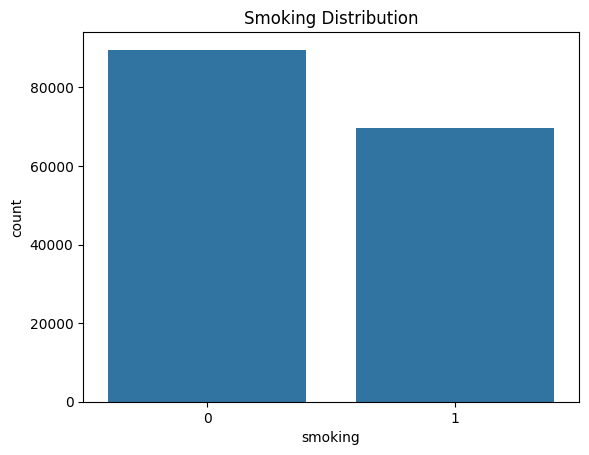

In [27]:
sns.countplot(x='smoking', data=df)

plt.title("Smoking Distribution")
plt.show()

The smoking distribution shows that non-smokers (0) are slightly more than smokers (1). The dataset is relatively balanced, which is good for machine learning model training

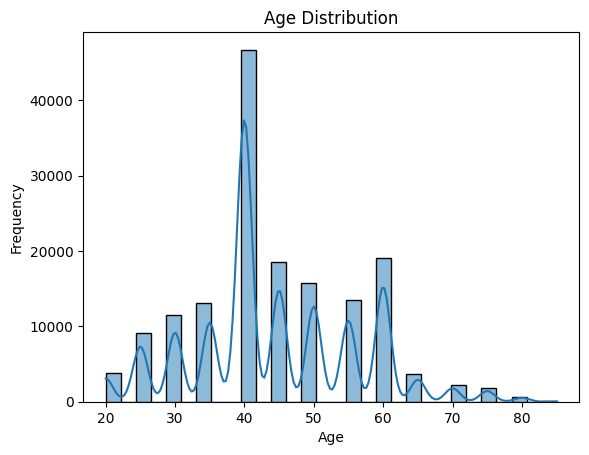

In [28]:
sns.histplot(df['age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

the blue smooth line is KDE Curve It shows the overall shape smoothly instead of blocky bars

he age distribution shows that most individuals are middle-aged, with a significant concentration around 40 years old. The number of samples decreases for older age groups, especially above 70 years. The distribution is slightly right-skewed and does not follow a perfect normal distribution.

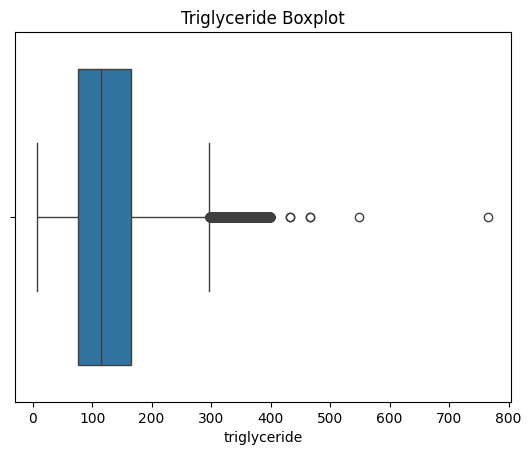

In [29]:
sns.boxplot(x=df['triglyceride'])

plt.title("Triglyceride Boxplot")

plt.show()

The triglyceride feature contains several high-value outliers. Most values are concentrated within a normal range, while a few samples have extremely large triglyceride measurements, causing the distribution to be right-skewed. (outlier is a value that is unusually far from most of the data)

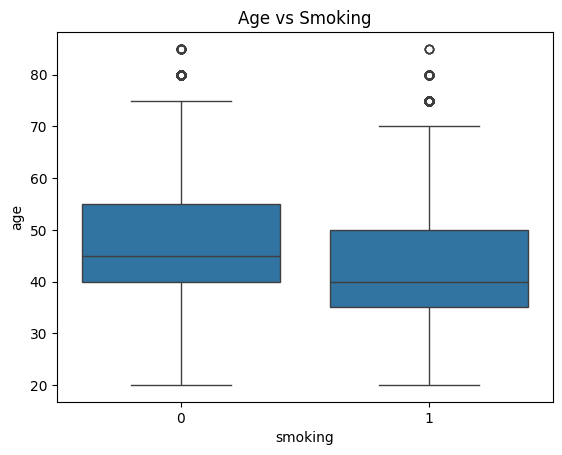

In [30]:
sns.boxplot(x='smoking', y='age', data=df)

plt.title("Age vs Smoking")

plt.show()

The boxplot shows that smokers tend to be slightly younger than non-smokers based on the median age values. Both groups contain a few older-age outliers.

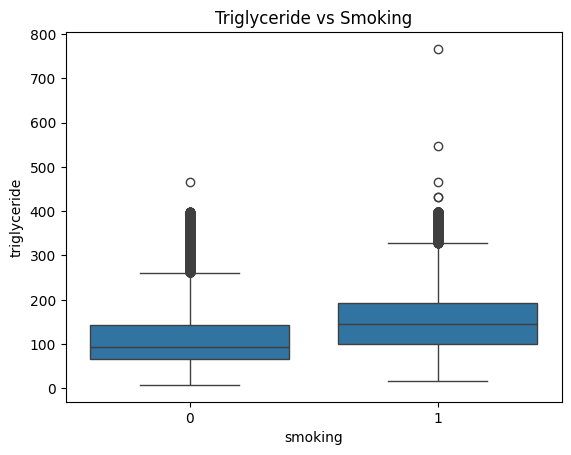

In [31]:
sns.boxplot(x='smoking', y='triglyceride', data=df)

plt.title("Triglyceride vs Smoking")

plt.show()

The boxplot indicates that smokers tend to have higher triglyceride levels compared to non-smokers. Smokers also show a larger spread and more extreme outlier values, suggesting that triglyceride may be an important feature for smoking prediction.

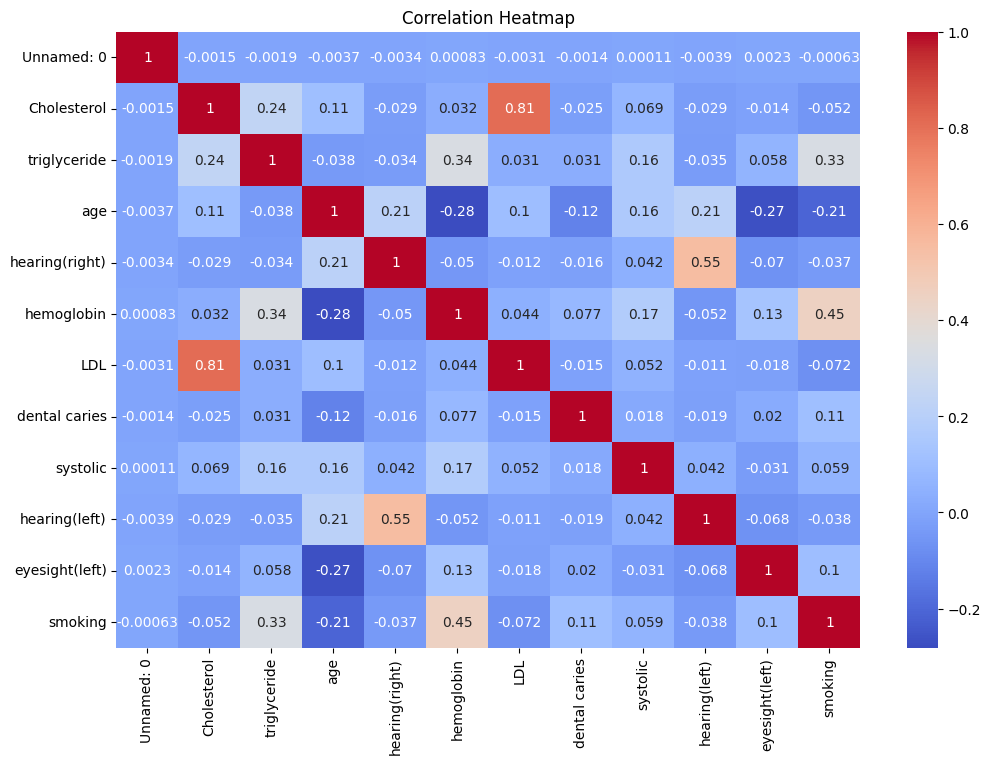

In [32]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap shows the relationship strength between different features. Hemoglobin and triglyceride have positive correlations with smoking, meaning higher values are more commonly associated with smokers in this dataset. Age has a slight negative correlation with smoking, suggesting that smoking appears less frequently in older individuals. The heatmap helps identify which features may be useful for predicting smoking status.

In [33]:
df_clean = df.copy() # Create a copy of the dataset before preprocessing

In [34]:
Q1 = df_clean['triglyceride'].quantile(0.25) #25% of values are below this number
Q3 = df_clean['triglyceride'].quantile(0.75) # calculate the third quartile (75%)

IQR = Q3 - Q1  #middle spread of normal data
#we use IQR to detect abnormal far-away values (outliers)
lower_bound = Q1 - 1.5 * IQR  #calculates minimum acceptable value anything BELOW this: considered outlier 
#we multiply by 1.5  cause its Standard statistical rule for outliers
upper_bound = Q3 + 1.5 * IQR  #calculates maximum acceptable value anything ABOVE this: considered outlier 
#formula produced negative number naturally
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -55.0
Upper Bound: 297.0


Triglyceride was selected for outlier handling because its boxplot showed several extreme high values compared to the normal data range. These outliers could negatively affect machine learning model performance, so the IQR method was applied to detect and remove them.

In [35]:
print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

Original Shape: (159256, 12)
Cleaned Shape: (159256, 12)


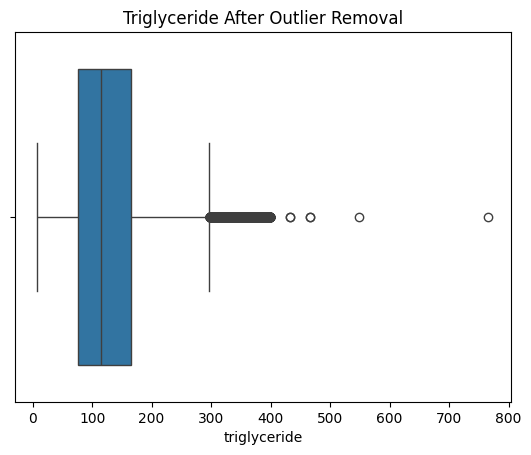

In [36]:
sns.boxplot(x=df_clean['triglyceride'])

plt.title("Triglyceride After Outlier Removal")

plt.show()

After applying the IQR method, extreme triglyceride outliers were removed from the dataset. The dataset size decreased slightly, and the updated boxplot shows a cleaner distribution with fewer extreme values.

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

numerical_columns = [
    'hemoglobin',
    'waist(cm)',
    'age',
    'triglyceride',
    'serum creatinine',
    'systolic',
    'eyesight(right)',
    'relaxation'
]

df_clean[numerical_columns] = scaler.fit_transform( #the fit here learns mean + standard deviation
    df_clean[numerical_columns] #apply scaling ONLY to the selected columns
)

df_clean.head()

KeyError: "['waist(cm)', 'serum creatinine', 'eyesight(right)', 'relaxation'] not in index"

We used StandardScaler to standardize the numerical features using the formula:
Z = (X - μ) / σ
where:
X = original value
μ = mean
σ = standard deviation

Feature scaling was applied to normalize numerical features into a similar range. This helps machine learning models train more effectively and prevents features with larger numerical values from dominating the learning process.

Conclusion

The exploratory analysis provided important insights into the dataset structure and feature relationships. Several features such as hemoglobin and triglyceride showed noticeable relationships with smoking status. Outliers were detected mainly in triglyceride values and were handled using the IQR method. Feature scaling was also applied using StandardScaler to normalize numerical features and improve future model performance.